# EDA — Instacart Online Grocery Basket Analysis
**Tech Challenge — Fase 2 | POSTECH ML Engineering**

---

## Objetivo
Realizar uma Análise Exploratória de Dados (EDA) completa sobre o dataset do Instacart, compreendendo:
- A estrutura relacional dos arquivos
- O comportamento de compras dos usuários
- Padrões temporais de pedidos
- Distribuição de produtos, corredores e departamentos
- Taxas de reordem e fidelidade de produtos
- Insights para modelos preditivos

## Dataset
> **Fonte:** [Kaggle — InstaCart Online Grocery Basket Analysis](https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset)


In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Define um estilo global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.figsize": (12, 5),
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
    }
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = os.path.join("..", "data", "raw")
print(f"Diretório de dados: {os.path.abspath(DATA_DIR)}")
print(f"Arquivos encontrados: {os.listdir(DATA_DIR)}")

Diretório de dados: c:\Users\gfrei\Documents\1. FIAP\4. FASE2\9. TECH_CHALLENGE\tech-challenge-2\data\raw
Arquivos encontrados: ['aisles.csv', 'aisles.csv.dvc', 'departments.csv', 'departments.csv.dvc', 'orders.csv', 'orders.csv.dvc', 'order_products__prior.csv', 'order_products__prior.csv.dvc', 'order_products__train.csv', 'order_products__train.csv.dvc', 'products.csv', 'products.csv.dvc']


---
## 1. Carregamento e Visão Geral dos Dados


In [35]:
# ── 1.1 Carregamento dos arquivos
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
order_products_prior = pd.read_csv(os.path.join(DATA_DIR, "order_products__prior.csv"))
order_products_train = pd.read_csv(os.path.join(DATA_DIR, "order_products__train.csv"))
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"))
aisles = pd.read_csv(os.path.join(DATA_DIR, "aisles.csv"))
departments = pd.read_csv(os.path.join(DATA_DIR, "departments.csv"))

datasets = {
    "orders": orders,
    "order_products__prior": order_products_prior,
    "order_products__train": order_products_train,
    "products": products,
    "aisles": aisles,
    "departments": departments,
}

print("=" * 65)
print(f"{'Dataset':<30} {'Shape':>15} {'Mem (MB)':>10}")
print("=" * 65)
for name, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name:<30} {str(df.shape):>15} {mem:>10.2f}")
print("=" * 65)

Dataset                                  Shape   Mem (MB)
orders                            (3421083, 7)     332.71
order_products__prior            (32434489, 4)     989.82
order_products__train             (1384617, 4)      42.26
products                            (49688, 4)       4.93
aisles                                (134, 2)       0.01
departments                            (21, 2)       0.00


In [4]:
# ── 1.2 Schema e tipos de dados
for name, df in datasets.items():
    print(f"\n{'─' * 55}")
    print(f"  {name.upper()}")
    print(f"{'─' * 55}")
    display(df.dtypes.to_frame("dtype").T)
    display(df.head(3))


───────────────────────────────────────────────────────
  ORDERS
───────────────────────────────────────────────────────


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
dtype,int64,int64,object,int64,int64,int64,float64


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0000
2,473747,1,prior,3,3,12,21.0000



───────────────────────────────────────────────────────
  ORDER_PRODUCTS__PRIOR
───────────────────────────────────────────────────────


,order_id,product_id,add_to_cart_order,reordered
dtype,int64,int64,int64,int64


...

,aisle_id,aisle
dtype,int64,object


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



───────────────────────────────────────────────────────
  DEPARTMENTS
───────────────────────────────────────────────────────


,department_id,department
dtype,int64,object


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


In [5]:
# ── 1.3 Qualidade de dados — valores nulos
print("Valores nulos por coluna:\n")
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        pct = (nulls / len(df) * 100).round(2)
        summary = pd.DataFrame({"null_count": nulls, "null_pct_%": pct})
        print(f"  [{name}]")
        display(summary)
    else:
        print(f"  [{name}] ✓ sem nulos")

Valores nulos por coluna:

  [orders]


,null_count,null_pct_%
days_since_prior_order,206209,6.0300


  [order_products__prior] ✓ sem nulos
  [order_products__train] ✓ sem nulos
  [products] ✓ sem nulos
  [aisles] ✓ sem nulos
  [departments] ✓ sem nulos


In [6]:
# ── 1.4 Duplicatas
print("Verificação de duplicatas:\n")
for name, df in datasets.items():
    dups = df.duplicated().sum()
    status = "⚠️  DUPLICATAS" if dups > 0 else "✓ sem duplicatas"
    print(f"  [{name}] {status}: {dups:,}")

Verificação de duplicatas:

  [orders] ✓ sem duplicatas: 0
  [order_products__prior] ✓ sem duplicatas: 0
  [order_products__train] ✓ sem duplicatas: 0
  [products] ✓ sem duplicatas: 0
  [aisles] ✓ sem duplicatas: 0
  [departments] ✓ sem duplicatas: 0


---
## 2. Análise do Dataset `orders`


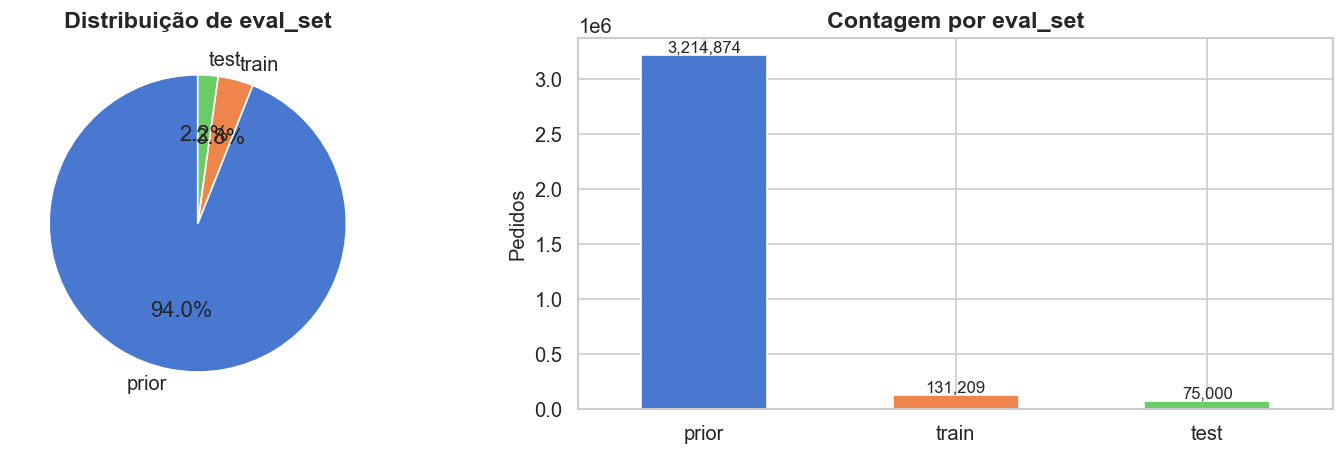

          contagem  percentual
eval_set                      
prior      3214874     93.9700
train       131209      3.8400
test         75000      2.1900


In [7]:
# ── 2.1 Distribuição dos conjuntos (prior / train / test)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

eval_counts = orders["eval_set"].value_counts()
axes[0].pie(
    eval_counts.values,
    labels=eval_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("muted", 3),
)
axes[0].set_title("Distribuição de eval_set")

eval_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("muted", 3))
axes[1].set_title("Contagem por eval_set")
axes[1].set_xlabel("")
axes[1].set_ylabel("Pedidos")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

print(
    eval_counts.to_frame("contagem").assign(
        percentual=lambda x: (x["contagem"] / x["contagem"].sum() * 100).round(2)
    )
)

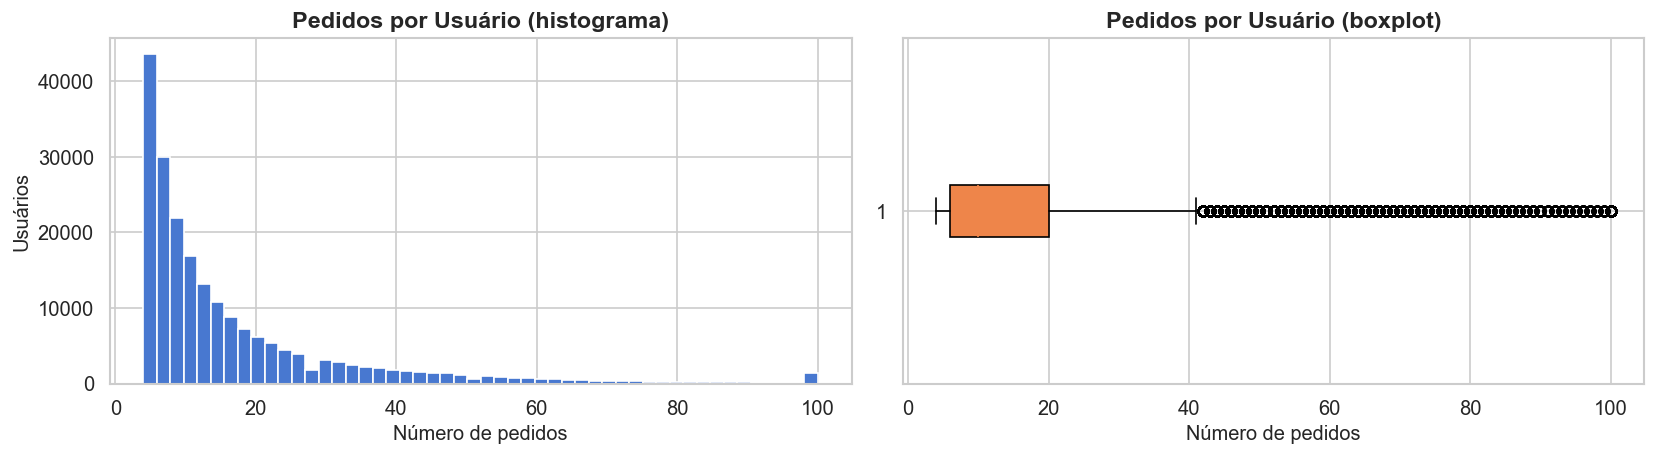

Estatísticas — pedidos por usuário:
count   206209.0000
mean        16.5900
std         16.6500
min          4.0000
25%          6.0000
50%         10.0000
75%         20.0000
max        100.0000
Name: order_id, dtype: float64


In [8]:
# ── 2.2 Distribuição de pedidos por usuário
orders_per_user = orders.groupby("user_id")["order_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    orders_per_user, bins=50, color=sns.color_palette("muted")[0], edgecolor="white"
)
axes[0].set_title("Pedidos por Usuário (histograma)")
axes[0].set_xlabel("Número de pedidos")
axes[0].set_ylabel("Usuários")

axes[1].boxplot(
    orders_per_user,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=sns.color_palette("muted")[1]),
)
axes[1].set_title("Pedidos por Usuário (boxplot)")
axes[1].set_xlabel("Número de pedidos")

plt.tight_layout()
plt.show()

print("Estatísticas — pedidos por usuário:")
print(orders_per_user.describe().round(2))

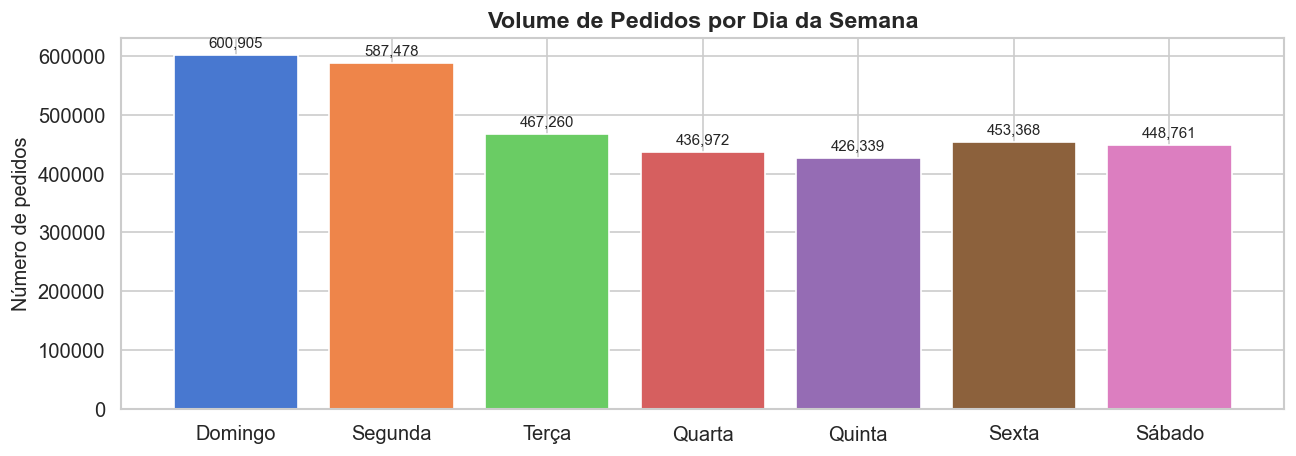

In [9]:
# ── 2.3 Dia da semana dos pedidos
dow_map = {
    0: "Domingo",
    1: "Segunda",
    2: "Terça",
    3: "Quarta",
    4: "Quinta",
    5: "Sexta",
    6: "Sábado",
}
orders["dow_name"] = orders["order_dow"].map(dow_map)

dow_counts = orders.groupby(["order_dow", "dow_name"])["order_id"].count().reset_index()
dow_counts.columns = ["order_dow", "dow_name", "count"]
dow_counts = dow_counts.sort_values("order_dow")

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(
    dow_counts["dow_name"], dow_counts["count"], color=sns.color_palette("muted", 7)
)
ax.set_title("Volume de Pedidos por Dia da Semana")
ax.set_xlabel("")
ax.set_ylabel("Número de pedidos")
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8000,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

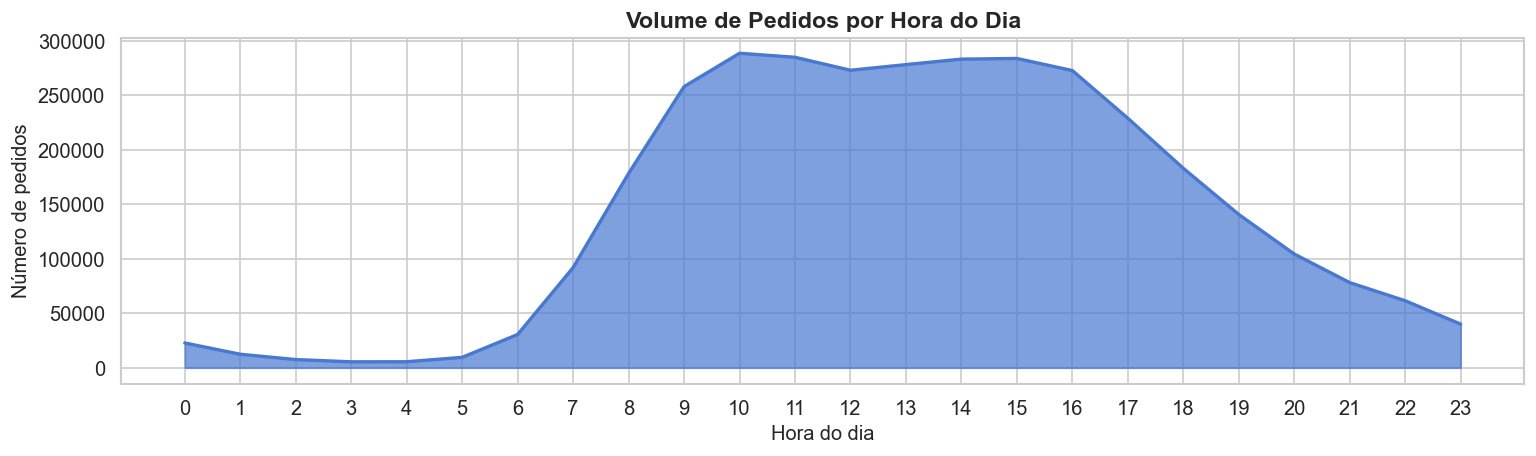

Hora de pico: 10h (288,418 pedidos)
Hora mais tranquila: 3h (5,474 pedidos)


In [10]:
# ── 2.4 Hora do dia dos pedidos
hour_counts = orders.groupby("order_hour_of_day")["order_id"].count()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    hour_counts.index,
    hour_counts.values,
    color=sns.color_palette("muted")[0],
    alpha=0.7,
)
ax.plot(
    hour_counts.index,
    hour_counts.values,
    color=sns.color_palette("muted")[0],
    linewidth=2,
)
ax.set_title("Volume de Pedidos por Hora do Dia")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Número de pedidos")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Hora de pico: {hour_counts.idxmax()}h ({hour_counts.max():,} pedidos)")
print(f"Hora mais tranquila: {hour_counts.idxmin()}h ({hour_counts.min():,} pedidos)")

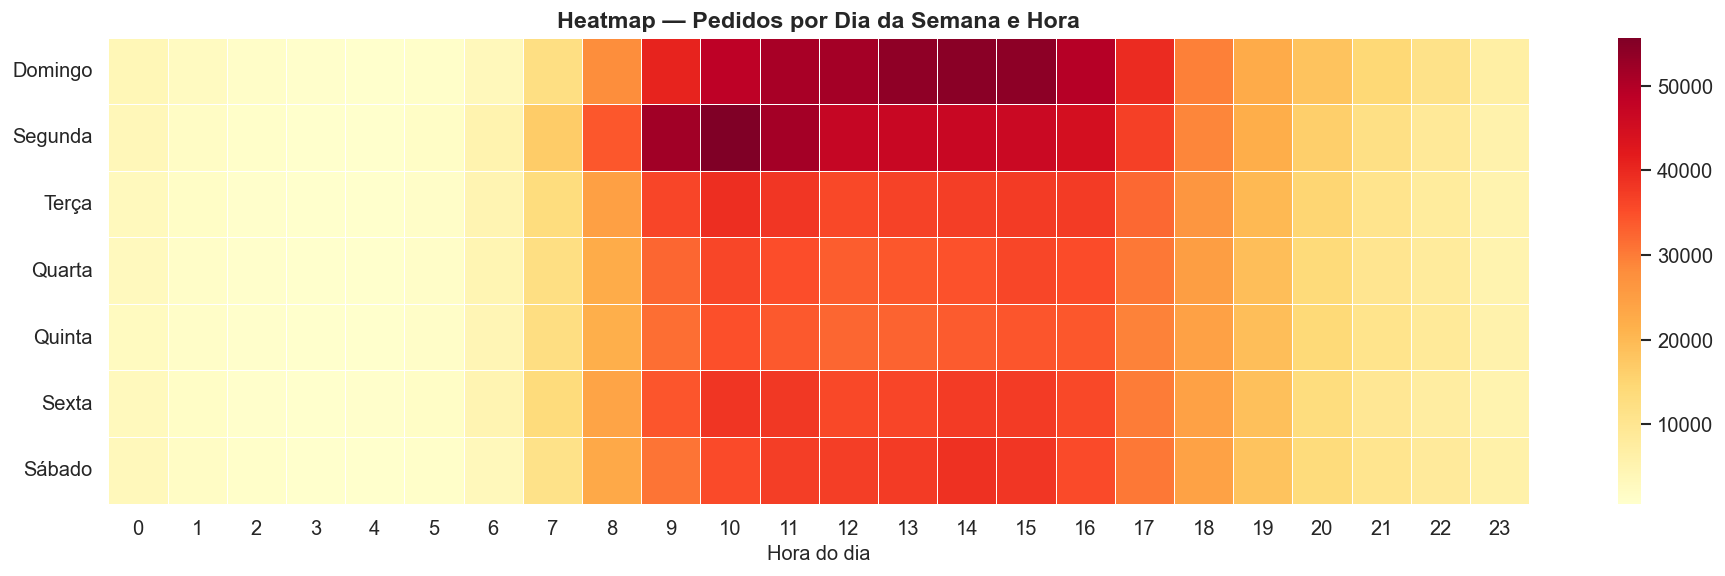

In [11]:
# ── 2.5 Heatmap: Dia da semana × Hora do dia
pivot = orders.groupby(["order_dow", "order_hour_of_day"])["order_id"].count().unstack()
pivot.index = [dow_map[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", fmt=",d", annot=False, linewidths=0.3, ax=ax)
ax.set_title("Heatmap — Pedidos por Dia da Semana e Hora")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

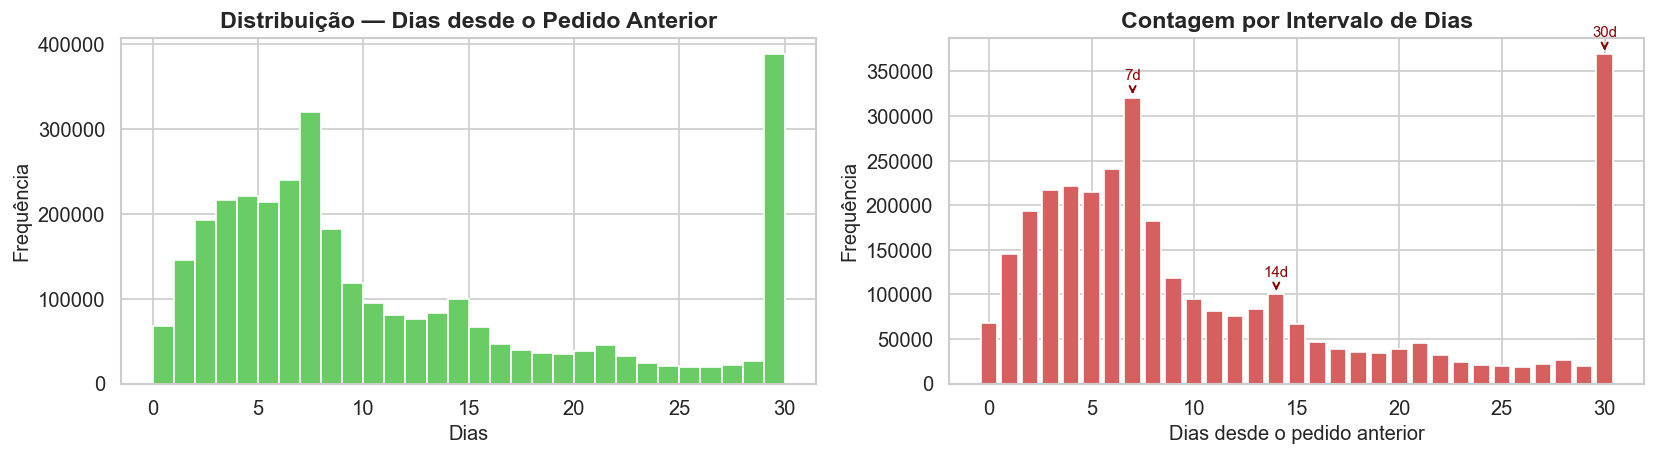

Estatísticas — days_since_prior_order:
count   3214874.0000
mean         11.1100
std           9.2100
min           0.0000
25%           4.0000
50%           7.0000
75%          15.0000
max          30.0000
Name: days_since_prior_order, dtype: float64


In [12]:
# ── 2.6 Intervalo desde o pedido anterior (days_since_prior_order)
dspo = orders["days_since_prior_order"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dspo, bins=30, color=sns.color_palette("muted")[2], edgecolor="white")
axes[0].set_title("Distribuição — Dias desde o Pedido Anterior")
axes[0].set_xlabel("Dias")
axes[0].set_ylabel("Frequência")

# detalhe nos picos (7, 14, 30)
dspo_counts = dspo.value_counts().sort_index()
axes[1].bar(
    dspo_counts.index,
    dspo_counts.values,
    color=sns.color_palette("muted")[3],
    edgecolor="white",
)
axes[1].set_title("Contagem por Intervalo de Dias")
axes[1].set_xlabel("Dias desde o pedido anterior")
axes[1].set_ylabel("Frequência")
for peak in [7, 14, 30]:
    if peak in dspo_counts.index:
        axes[1].annotate(
            f"{peak}d",
            xy=(peak, dspo_counts[peak]),
            xytext=(peak, dspo_counts[peak] + 20000),
            ha="center",
            fontsize=9,
            color="darkred",
            arrowprops=dict(arrowstyle="->", color="darkred", lw=1.2),
        )
plt.tight_layout()
plt.show()

print("Estatísticas — days_since_prior_order:")
print(dspo.describe().round(2))

---
## 3. Análise de Produtos, Corredores e Departamentos


In [13]:
# ── 3.1 Enriquecer catálogo de produtos
products_full = products.merge(aisles, on="aisle_id", how="left").merge(
    departments, on="department_id", how="left"
)

print(f"Produtos únicos: {products_full['product_id'].nunique():,}")
print(f"Corredores únicos: {products_full['aisle_id'].nunique()}")
print(f"Departamentos únicos: {products_full['department_id'].nunique()}")
display(products_full.head())

Produtos únicos: 49,688
Corredores únicos: 134
Departamentos únicos: 21


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


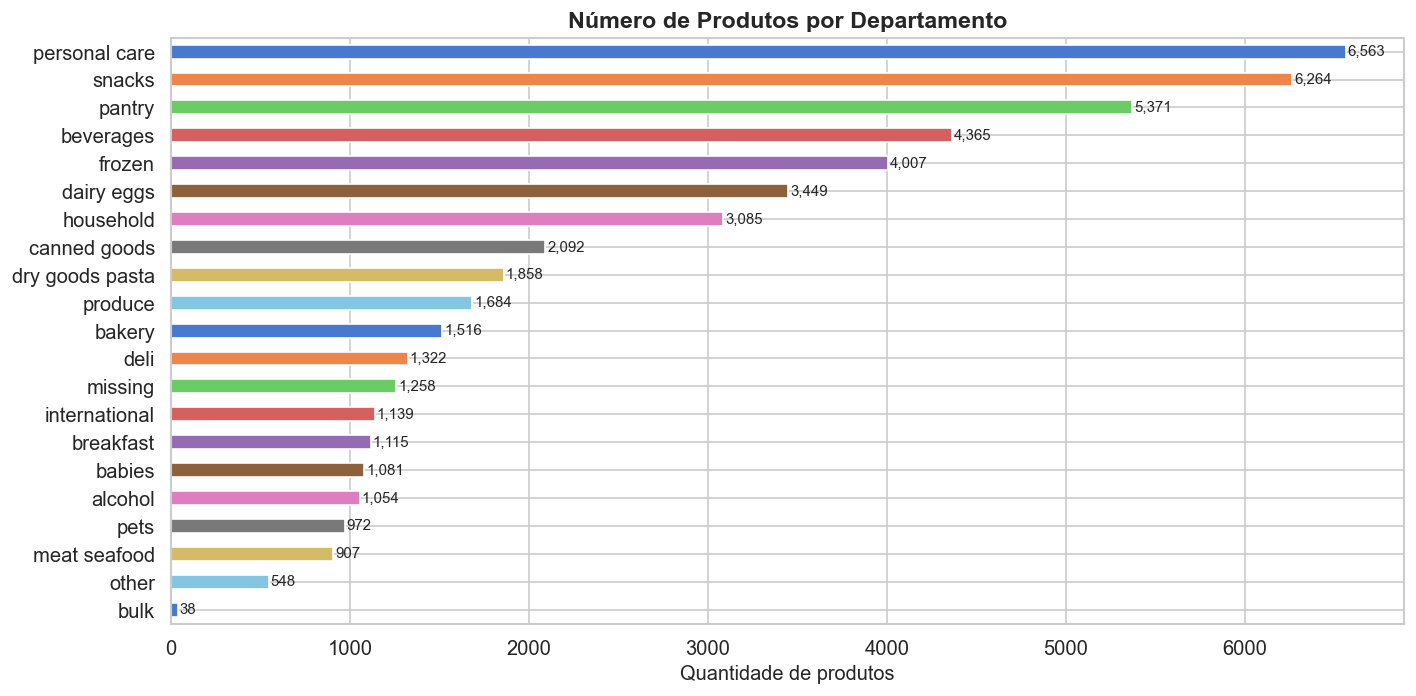

In [14]:
# ── 3.2 Produtos por departamento
dept_products = (
    products_full.groupby("department")["product_id"]
    .count()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
dept_products.plot(
    kind="barh", ax=ax, color=sns.color_palette("muted", len(dept_products))
)
ax.set_title("Número de Produtos por Departamento")
ax.set_xlabel("Quantidade de produtos")
ax.set_ylabel("")
ax.invert_yaxis()
for i, v in enumerate(dept_products.values):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

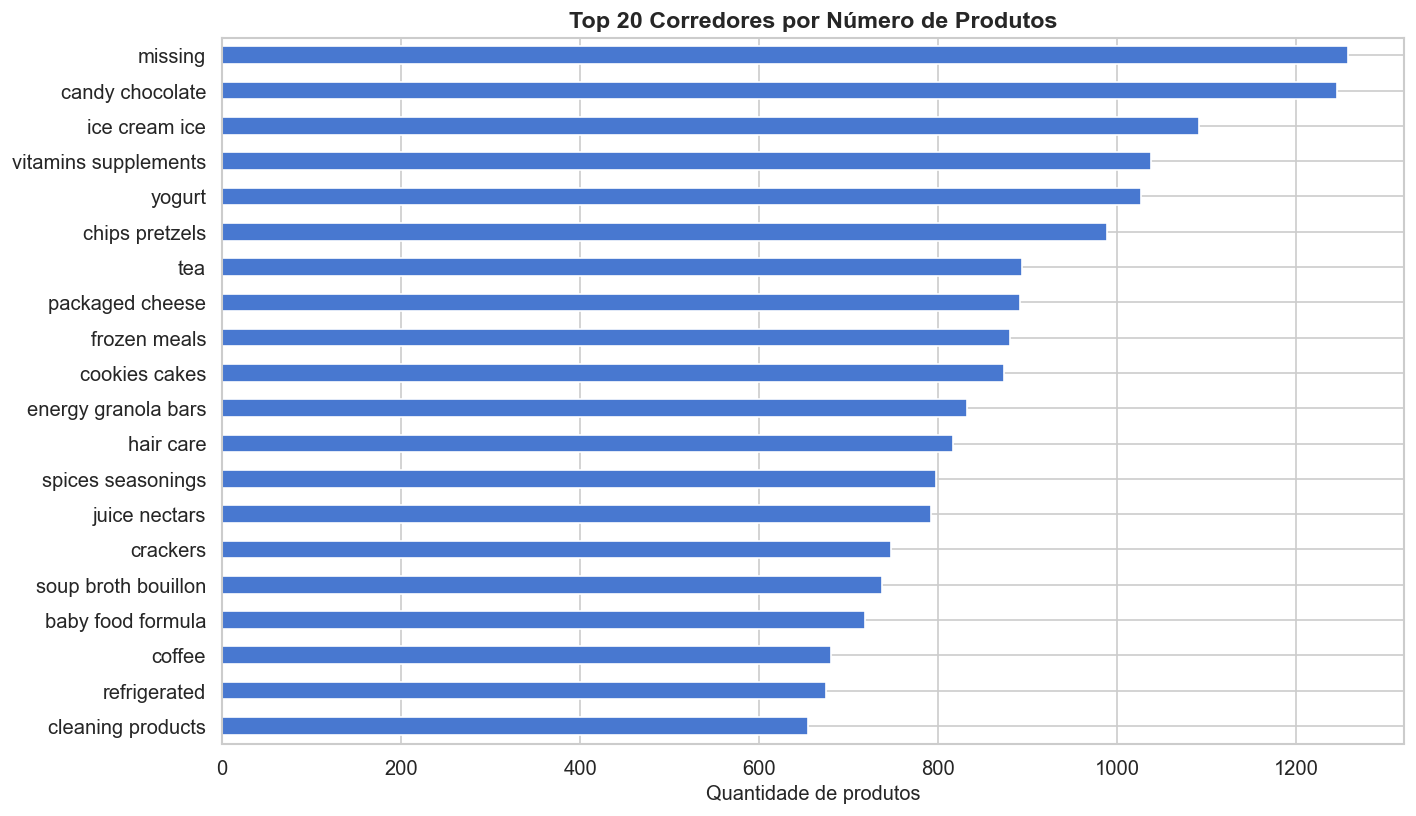

In [15]:
# ── 3.3 Top 20 corredores com mais produtos
top_aisles = (
    products_full.groupby("aisle")["product_id"]
    .count()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
top_aisles.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[0])
ax.set_title("Top 20 Corredores por Número de Produtos")
ax.set_xlabel("Quantidade de produtos")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Análise dos Itens de Pedido (order_products)


In [16]:
# ── 4.1 Combinar prior e train para análise geral
order_products_all = pd.concat(
    [order_products_prior, order_products_train], ignore_index=True
)

print(f"Total de linhas (prior + train): {len(order_products_all):,}")
print(f"Pedidos únicos: {order_products_all['order_id'].nunique():,}")
print(f"Produtos únicos: {order_products_all['product_id'].nunique():,}")
display(order_products_all.head())

Total de linhas (prior + train): 33,819,106
Pedidos únicos: 3,346,083
Produtos únicos: 49,685


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


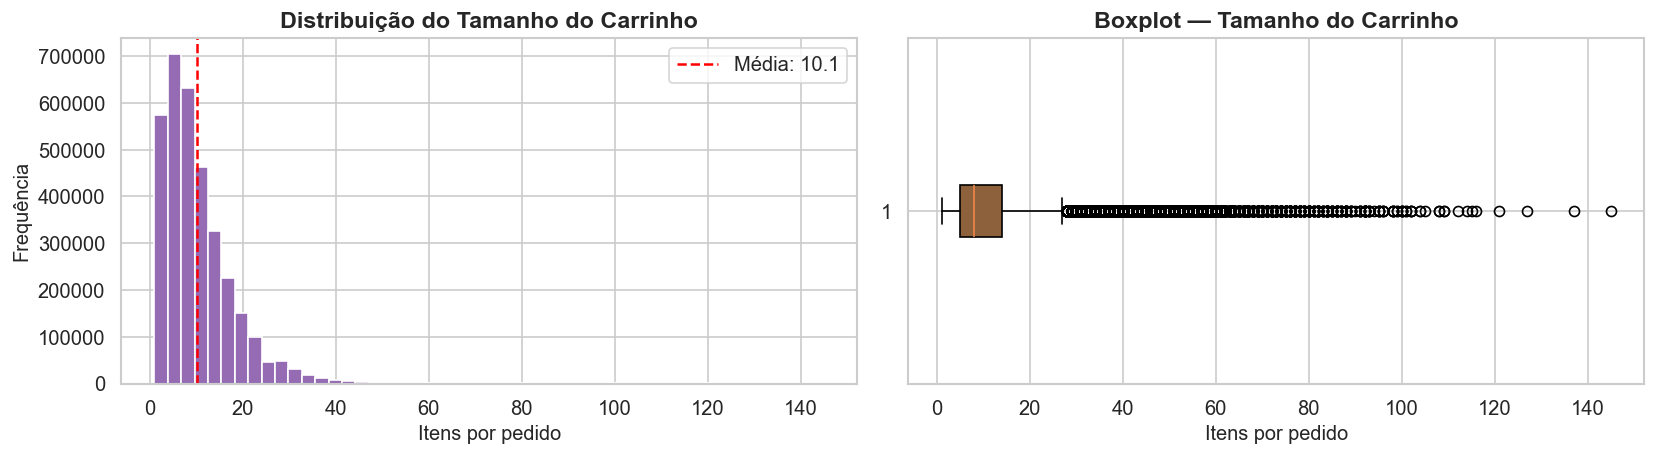

Estatísticas — tamanho do carrinho:
count   3346083.0000
mean         10.1100
std           7.5400
min           1.0000
25%           5.0000
50%           8.0000
75%          14.0000
max         145.0000
Name: product_id, dtype: float64


In [17]:
# ── 4.2 Tamanho dos carrinhos (itens por pedido)
cart_size = order_products_all.groupby("order_id")["product_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(cart_size, bins=50, color=sns.color_palette("muted")[4], edgecolor="white")
axes[0].set_title("Distribuição do Tamanho do Carrinho")
axes[0].set_xlabel("Itens por pedido")
axes[0].set_ylabel("Frequência")
axes[0].axvline(
    cart_size.mean(),
    color="red",
    linestyle="--",
    label=f"Média: {cart_size.mean():.1f}",
)
axes[0].legend()

axes[1].boxplot(
    cart_size,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=sns.color_palette("muted")[5]),
)
axes[1].set_title("Boxplot — Tamanho do Carrinho")
axes[1].set_xlabel("Itens por pedido")

plt.tight_layout()
plt.show()

print("Estatísticas — tamanho do carrinho:")
print(cart_size.describe().round(2))

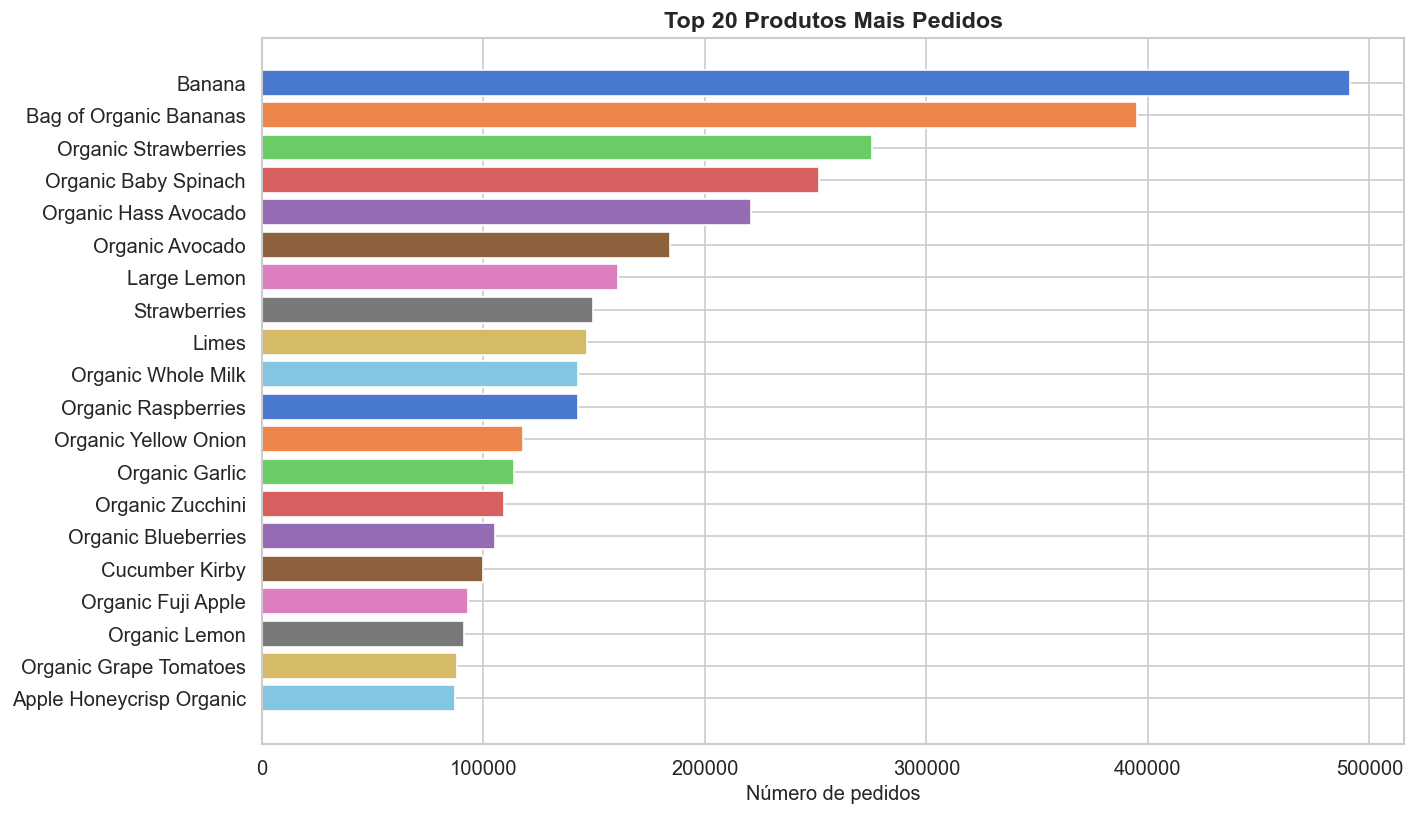

In [18]:
# ── 4.3 Top 20 produtos mais pedidos
top_products = (
    order_products_all.groupby("product_id")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .merge(products[["product_id", "product_name"]], on="product_id")
)

top_products.columns = ["product_id", "order_count", "product_name"]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    top_products["product_name"],
    top_products["order_count"],
    color=sns.color_palette("muted", 20),
)
ax.set_title("Top 20 Produtos Mais Pedidos")
ax.set_xlabel("Número de pedidos")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Taxa de reordem global: 59.01%


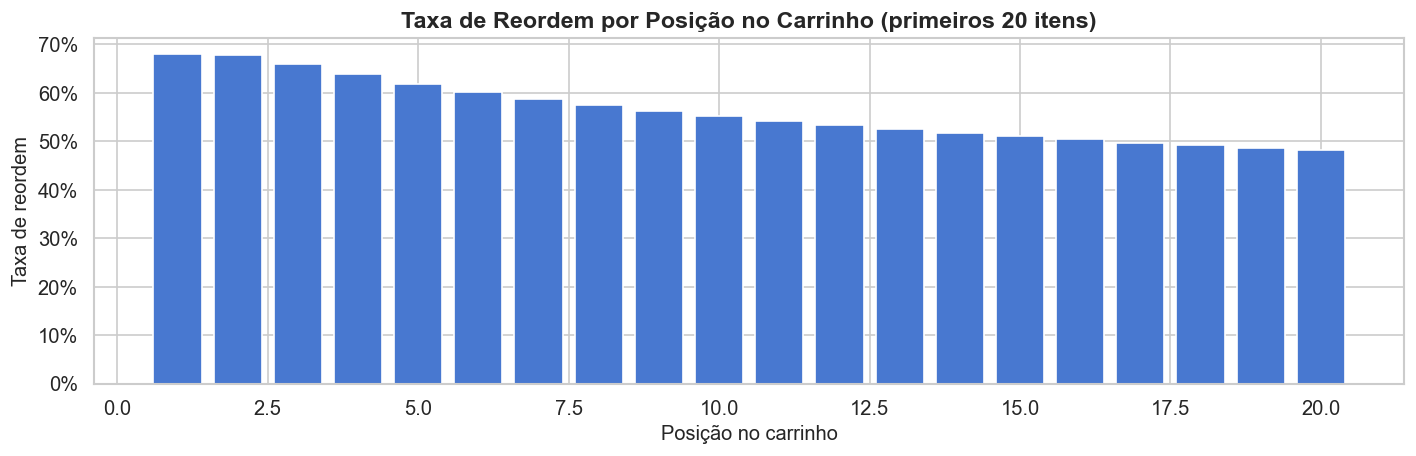

In [19]:
# ── 4.4 Taxa de reordem geral
reorder_rate = order_products_all["reordered"].mean()
print(f"Taxa de reordem global: {reorder_rate:.2%}")

# Por posição no carrinho (add_to_cart_order)
reorder_by_pos = (
    order_products_all.groupby("add_to_cart_order")["reordered"].mean().head(20)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(reorder_by_pos.index, reorder_by_pos.values, color=sns.color_palette("muted")[0])
ax.set_title("Taxa de Reordem por Posição no Carrinho (primeiros 20 itens)")
ax.set_xlabel("Posição no carrinho")
ax.set_ylabel("Taxa de reordem")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

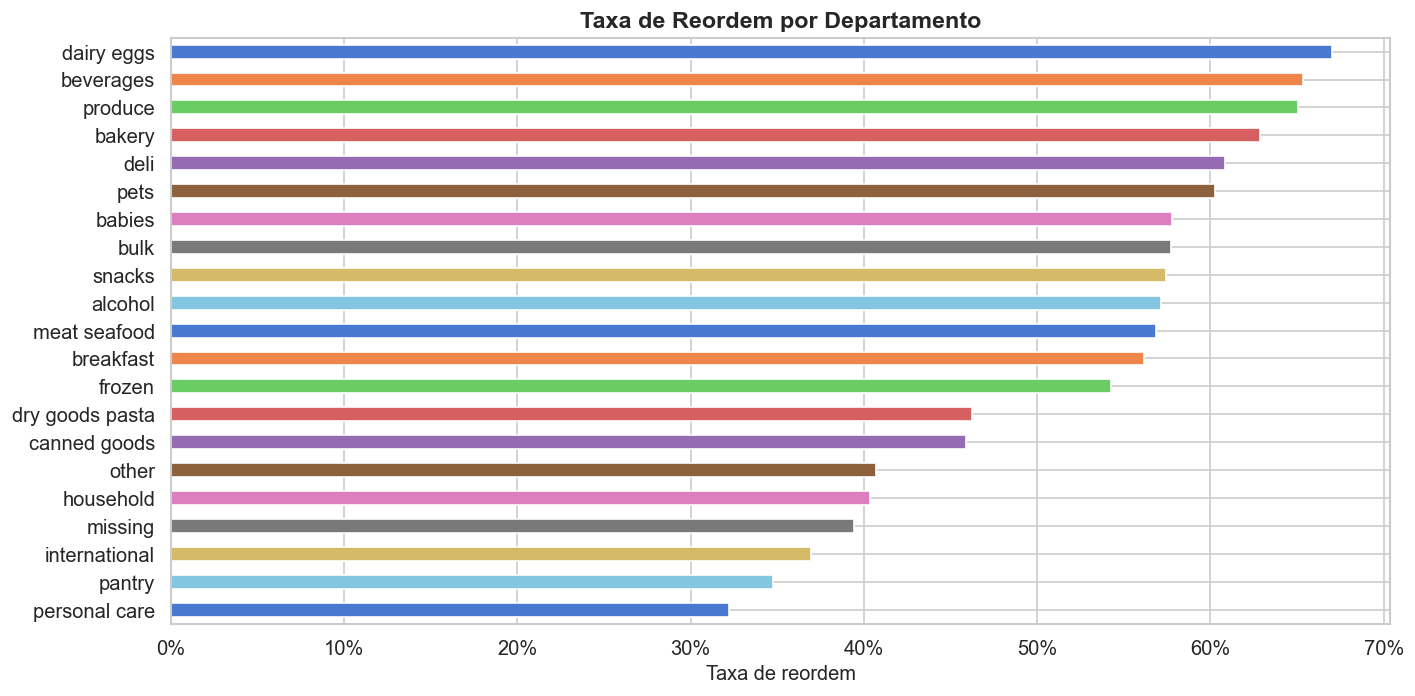

                 reorder_pct
department                  
dairy eggs           67.0200
beverages            65.3700
produce              65.0500
bakery               62.8400
deli                 60.8100
pets                 60.2600
babies               57.7700
bulk                 57.7100
snacks               57.4500
alcohol              57.1200
meat seafood         56.8600
breakfast            56.1400
frozen               54.2600
dry goods pasta      46.2200
canned goods         45.8600
other                40.7100
household            40.3300
missing              39.4300
international        36.9700
pantry               34.7400
personal care        32.1900


In [20]:
# ── 4.5 Taxa de reordem por departamento
reorder_dept = (
    order_products_all.merge(
        products[["product_id", "department_id"]], on="product_id", how="left"
    )
    .merge(departments, on="department_id", how="left")
    .groupby("department")["reordered"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
reorder_dept.plot(
    kind="barh", ax=ax, color=sns.color_palette("muted", len(reorder_dept))
)
ax.set_title("Taxa de Reordem por Departamento")
ax.set_xlabel("Taxa de reordem")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    reorder_dept.to_frame("reorder_rate")
    .assign(reorder_pct=lambda x: (x["reorder_rate"] * 100).round(2))
    .drop(columns=["reorder_rate"])
)

---
## 5. Comportamento de Recompra por Usuário


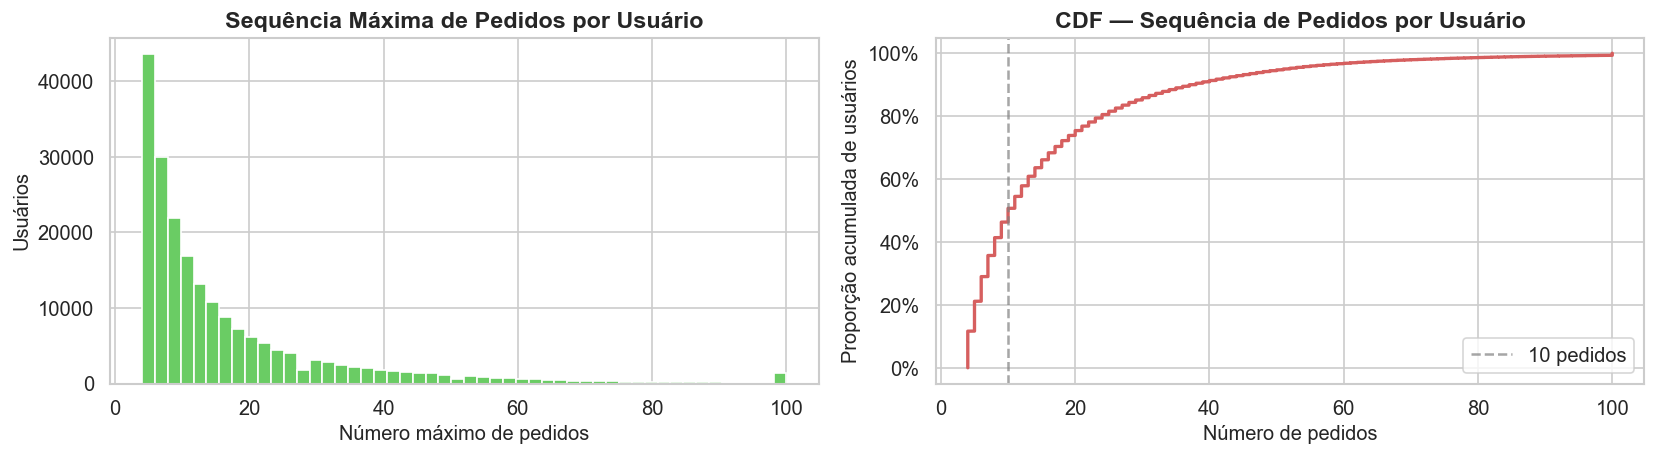

% de usuários com ≥10 pedidos: 53.70%
% de usuários com ≥30 pedidos: 14.88%


In [21]:
# ── 5.1 Número máximo de pedidos por usuário (fidelidade)
max_order_per_user = orders.groupby("user_id")["order_number"].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    max_order_per_user, bins=50, color=sns.color_palette("muted")[2], edgecolor="white"
)
axes[0].set_title("Sequência Máxima de Pedidos por Usuário")
axes[0].set_xlabel("Número máximo de pedidos")
axes[0].set_ylabel("Usuários")

# CDF
sorted_vals = np.sort(max_order_per_user)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color=sns.color_palette("muted")[3], linewidth=2)
axes[1].set_title("CDF — Sequência de Pedidos por Usuário")
axes[1].set_xlabel("Número de pedidos")
axes[1].set_ylabel("Proporção acumulada de usuários")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].axvline(10, color="gray", linestyle="--", alpha=0.7, label="10 pedidos")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"% de usuários com ≥10 pedidos: {(max_order_per_user >= 10).mean():.2%}")
print(f"% de usuários com ≥30 pedidos: {(max_order_per_user >= 30).mean():.2%}")

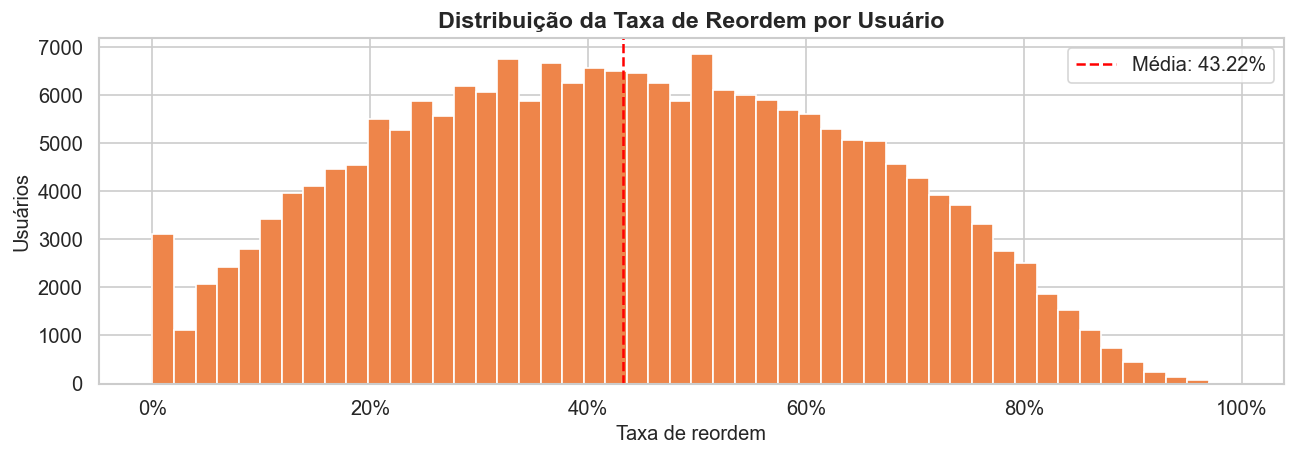

Estatísticas — taxa de reordem por usuário:
count    206209.0000
mean          0.4322
std           0.2121
min           0.0000
25%           0.2679
50%           0.4286
75%           0.5957
max           0.9895
Name: reordered, dtype: object


In [22]:
# ── 5.2 Taxa de reordem média por usuário (somente prior)
user_reorder = (
    order_products_prior.merge(
        orders[["order_id", "user_id"]], on="order_id", how="left"
    )
    .groupby("user_id")["reordered"]
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(user_reorder, bins=50, color=sns.color_palette("muted")[1], edgecolor="white")
ax.axvline(
    user_reorder.mean(),
    color="red",
    linestyle="--",
    label=f"Média: {user_reorder.mean():.2%}",
)
ax.set_title("Distribuição da Taxa de Reordem por Usuário")
ax.set_xlabel("Taxa de reordem")
ax.set_ylabel("Usuários")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

print("Estatísticas — taxa de reordem por usuário:")
print(user_reorder.describe().apply(lambda x: f"{x:.4f}"))

---
## 6. Análise de Produtos Orgânicos


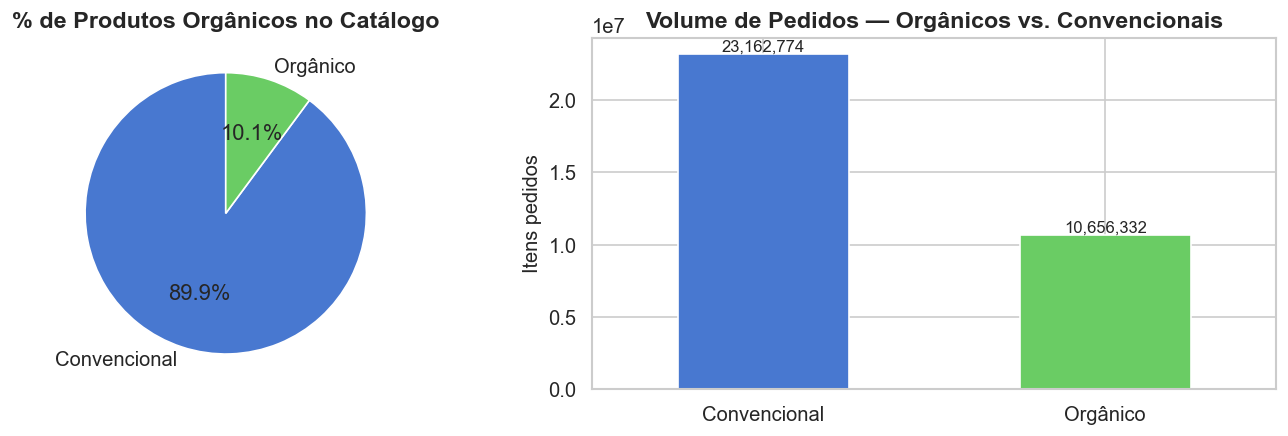

Taxa de reordem — Orgânicos vs. Convencionais:
Convencional    56.92%
Orgânico        63.54%
Name: reordered, dtype: object


In [23]:
# ── 6.1 Produtos orgânicos vs. convencionais
products_full["is_organic"] = (
    products_full["product_name"].str.lower().str.contains("organic")
)

organic_count = products_full["is_organic"].value_counts()
labels = ["Convencional", "Orgânico"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(
    organic_count.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=[sns.color_palette("muted")[0], sns.color_palette("muted")[2]],
    startangle=90,
)
axes[0].set_title("% de Produtos Orgânicos no Catálogo")

# Taxa de pedidos — orgânico vs convencional
op_organic = order_products_all.merge(
    products_full[["product_id", "is_organic"]], on="product_id", how="left"
)

organic_orders = op_organic.groupby("is_organic")["order_id"].count()
organic_orders.index = labels
organic_orders.plot(
    kind="bar",
    ax=axes[1],
    color=[sns.color_palette("muted")[0], sns.color_palette("muted")[2]],
)
axes[1].set_title("Volume de Pedidos — Orgânicos vs. Convencionais")
axes[1].set_ylabel("Itens pedidos")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

# Taxa de reordem orgânico vs convencional
reorder_organic = op_organic.groupby("is_organic")["reordered"].mean()
reorder_organic.index = labels
print("Taxa de reordem — Orgânicos vs. Convencionais:")
print(reorder_organic.apply(lambda x: f"{x:.2%}"))

---
## 7. Correlações e Matriz de Perfil do Usuário


In [24]:
# ── 7.1 Construção de features por usuário para análise de correlação
user_features = (
    orders[orders["eval_set"] != "test"]
    .groupby("user_id")
    .agg(
        total_orders=("order_id", "count"),
        avg_days_since_prior=("days_since_prior_order", "mean"),
        std_days_since_prior=("days_since_prior_order", "std"),
        avg_hour=("order_hour_of_day", "mean"),
        preferred_dow=("order_dow", lambda x: x.mode()[0]),
    )
    .reset_index()
)

# Juntar taxa de reordem
user_features = user_features.merge(
    user_reorder.rename("avg_reorder_rate").reset_index(), on="user_id", how="left"
)

print(f"Shape do perfil de usuário: {user_features.shape}")
display(user_features.describe().round(3))

Shape do perfil de usuário: (206209, 7)


,user_id,total_orders,avg_days_since_prior,std_days_since_prior,avg_hour,preferred_dow,avg_reorder_rate
count,206209.0000,206209.0000,206209.0000,206209.0000,206209.0000,206209.0000,206209.0000
mean,103105.0000,16.2270,15.3610,7.5850,13.5860,2.1010,0.4320
std,59527.5550,16.6620,6.9850,3.5090,2.0530,2.0720,0.2120
min,1.0000,3.0000,0.0000,0.0000,0.7500,0.0000,0.0000
25%,51553.0000,6.0000,9.6670,5.1500,12.2500,0.0000,0.2680
50%,103105.0000,10.0000,14.8000,8.0070,13.5710,1.0000,0.4290
75%,154657.0000,20.0000,20.5000,10.0110,14.9230,4.0000,0.5960
max,206209.0000,100.0000,30.0000,21.2130,23.0000,6.0000,0.9900


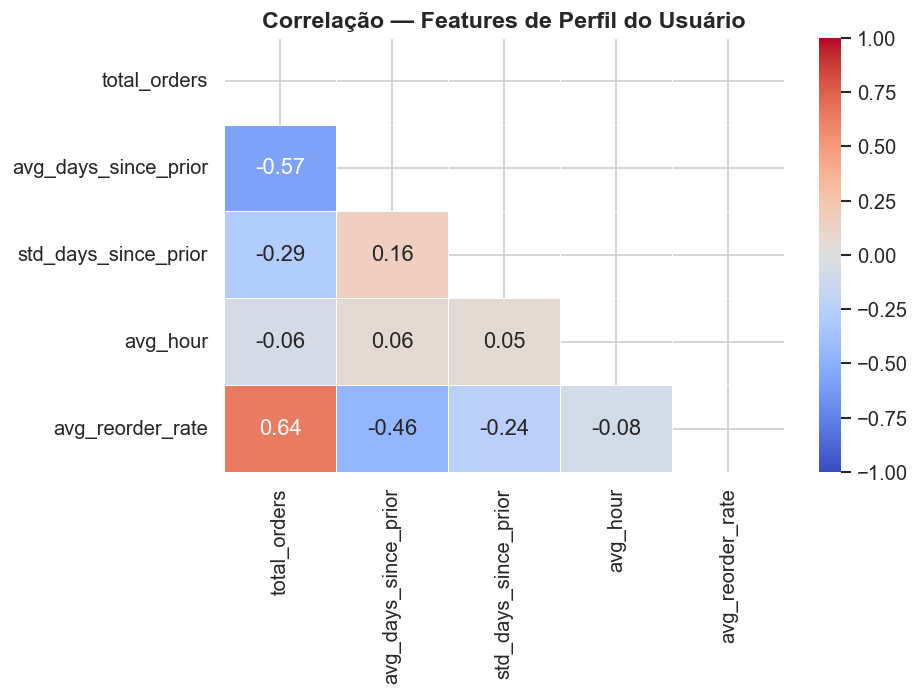

In [25]:
# ── 7.2 Heatmap de correlação das features de usuário
num_cols = [
    "total_orders",
    "avg_days_since_prior",
    "std_days_since_prior",
    "avg_hour",
    "avg_reorder_rate",
]
corr = user_features[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlação — Features de Perfil do Usuário")
plt.tight_layout()
plt.show()

---
## 8. Insights e Conclusões da EDA


In [26]:
# ── 8.1 Sumário estatístico consolidado
print("=" * 60)
print("  SUMÁRIO ESTATÍSTICO — INSTACART EDA")
print("=" * 60)
print(f"  Usuários únicos:         {orders['user_id'].nunique():>12,}")
print(f"  Pedidos totais:          {orders['order_id'].nunique():>12,}")
print(f"  Produtos únicos:         {products['product_id'].nunique():>12,}")
print(f"  Corredores:              {aisles['aisle_id'].nunique():>12,}")
print(f"  Departamentos:           {departments['department_id'].nunique():>12,}")
print(f"  Itens totais (prior):    {len(order_products_prior):>12,}")
print(f"  Itens totais (train):    {len(order_products_train):>12,}")
print("-" * 60)
print(
    f"  Média de pedidos/usuário:{orders.groupby('user_id')['order_id'].count().mean():>12.1f}"
)
print(f"  Média de itens/pedido:   {cart_size.mean():>12.1f}")
print(f"  Taxa global de reordem:  {order_products_all['reordered'].mean():>12.2%}")
print(f"  % produtos orgânicos:    {products_full['is_organic'].mean():>12.2%}")
print(f"  Hora de pico (pedidos):  {hour_counts.idxmax():>11}h")
print(
    f"  Dia mais movimentado:    {dow_counts.loc[dow_counts['count'].idxmax(), 'dow_name']:>12}"
)
print("=" * 60)

  SUMÁRIO ESTATÍSTICO — INSTACART EDA
  Usuários únicos:              206,209
  Pedidos totais:             3,421,083
  Produtos únicos:               49,688
  Corredores:                       134
  Departamentos:                     21
  Itens totais (prior):      32,434,489
  Itens totais (train):       1,384,617
------------------------------------------------------------
  Média de pedidos/usuário:        16.6
  Média de itens/pedido:           10.1
  Taxa global de reordem:        59.01%
  % produtos orgânicos:          10.14%
  Hora de pico (pedidos):           10h
  Dia mais movimentado:         Domingo


---
## 9. Insights para Modelagem

### 🔑 Principais descobertas

1. **Comportamento temporal**: A maioria dos pedidos ocorre nos fins de semana (domingo e sábado), com pico entre 10h–15h. Isso sugere features como `is_weekend`, `is_peak_hour`.

2. **Intervalos de recompra**: Os picos em 7, 14 e 30 dias revelam ciclos de compra semanais/mensais. `days_since_prior_order` é uma feature de alta importância para reordem.

3. **Tamanho do carrinho**: A distribuição é assimétrica à direita (mediana ~8 itens). Carrinhos grandes tendem a ter maior taxa de reordem.

4. **Fidelidade do usuário**: Mais de 50% dos usuários têm 10+ pedidos históricos — base rica para features de sequência temporal.

5. **Orgânicos**: Apesar de representarem ~10% do catálogo, têm taxa de reordem superior à média, indicando alta fidelidade de consumo.

6. **Posição no carrinho**: Itens adicionados primeiro ao carrinho têm maior taxa de reordem — sugerem hábito estabelecido.

7. **Departamentos campeões em reordem**: *Produce*, *Dairy Eggs* e *Beverages* dominam em volume e reordem.

### 🎯 Features candidatas para modelagem de reordem

| Feature | Origem | Tipo |
|---|---|---|
| `user_avg_reorder_rate` | orders + order_products | Numérica |
| `product_reorder_rate` | order_products | Numérica |
| `user_product_order_count` | order_products | Numérica |
| `days_since_prior_order` | orders | Numérica |
| `order_dow` / `order_hour_of_day` | orders | Categórica |
| `add_to_cart_order` | order_products | Numérica |
| `is_organic` | products | Binária |
| `department_id` / `aisle_id` | products | Categórica |
| `days_since_last_bought` | orders + order_products | Numérica |
